# Putting many TinyRNNs onto one GPU

Here we investigate a potential speed-up obtained by training many TinyRNNs with the same training data. This means we can run all hyperparameters on the same loop. Could be an upwards of 100x speed up.

In [1]:
%load_ext autoreload

from NM_TinyRNN.code.models import training
from NM_TinyRNN.code.models import datasets as ds
from NM_TinyRNN.code.models import rnns
# write some code to further parallelise the training and test it here
from NM_TinyRNN.code.models import nested_cv as nc
from NM_TinyRNN.code.models import save_data
from NM_TinyRNN.code.models import submit_jobs

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload


CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:

# let's test some code!
test_data_path = DATA_PATH / "bayes_optimal"
test_save_path  = './NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy'
reload(save_data)
reload(ds)
reload(nc)
reload(rnns)
reload(training)

input_encoding = 'onehot'
input_forced_choice = True

subject_data_path = DATA_PATH/'WS16'
#ws_subject_list = ['WS01','WS02','WS05','WS08','WS09','WS10','WS13','WS14','WS16','WS18','WS20','WS22']
dataset = ds.AB_Dataset(subject_data_path, sequence_length = 64,
                        input_encoding=input_encoding,input_forced_choice=input_forced_choice)
input_size = dataset.inputs.shape[-1]
model = rnns.TinyRNN(rnn_type = 'vanilla', nonlinearity = 'tanh', hidden_size = 1, init_decoder = False,
                     input_size=input_size, input_encoding=input_encoding,input_forced_choice = input_forced_choice,
                     decoder_bias = True)

# we use a trainer with ensemble model training across hyperparameters
trainer = training.Trainer(weight_seeds = list(range(1,11)),
                        sparsity_lambdas = [1e-1,1e-2,1e-3,1e-4,1e-5],
                        energy_lambdas = [1e-1,1e-2,1e-3],
                        hebbian_lambdas = [0.0],
                        covariance_lambdas = [0.0],
                        batch_size = 16)
final_state_dict, config, loss_dict = trainer.fit(model, dataset)


Sequence length 64 excludes 7.1% of trials
Parallelizing 150 models on cpu
Data split (session-level): 15 train, 2 validation, and 2 evaluation


  1%|          | 80/10000 [00:17<36:57,  4.47it/s]

Search complete. Best model index: 129. Val. loss: 0.5146293044090271


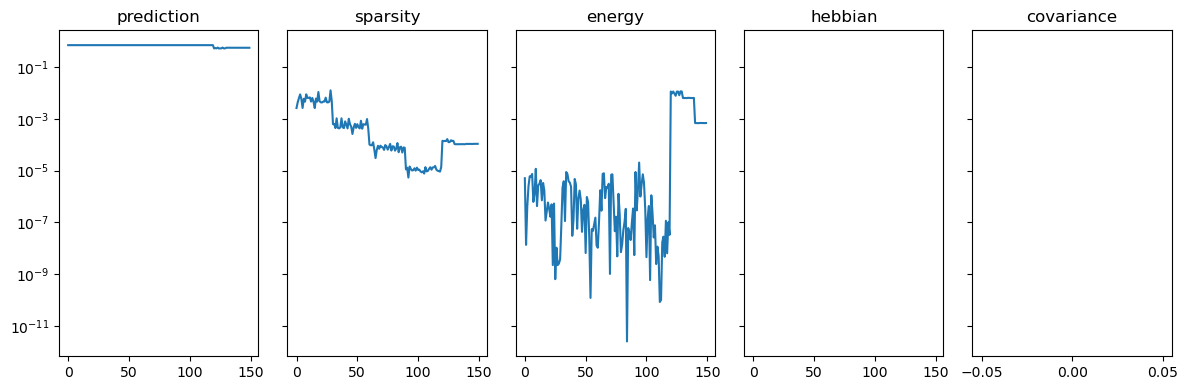

In [15]:
#plot losses
fig, ax = plt.subplots(1,len([x for x in loss_dict.keys()]), sharey=True, figsize=(12,4))
for i, (k,v) in enumerate(loss_dict.items()):
    ax[i].semilogy(np.arange(len(v)),v)
    ax[i].set_title(k)
plt.tight_layout()

ValueError: Could not interpret value `hidden_2` for `y`. An entry with this name does not appear in `data`.

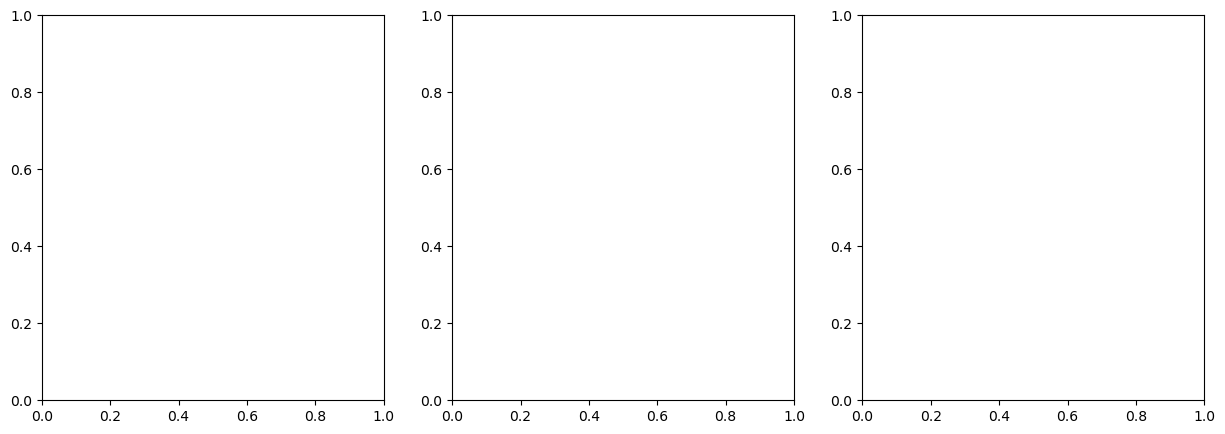

In [11]:
# let's look at a logit plot
model.load_state_dict(final_state_dict)
reload(save_data)
splits = nc.nested_cv_splits(dataset)
trials_df = save_data.get_model_trial_by_trial_df(model, dataset, splits['inner_folds'][0])
fig, ax = plt.subplots(1,3, figsize = (15,5))
sns.scatterplot(trials_df.query('forced_choice==0'), 
                x='hidden_1', y='hidden_2', 
                hue='logit_value', palette='coolwarm', 
                ax =ax[0])
sns.scatterplot(trials_df.query('forced_choice==0'), 
                x='logit_value', y='logit_change', hue='trial_type', ax =ax[1])
sns.scatterplot(trials_df.query('forced_choice==0'), 
                x='logit_value', y='logit_change', hue='gate_update_2', ax = ax[2])
[x.axis('square') for x in ax]
fig.tight_layout()

In [16]:
print(config)
final_state_dict

(1e-05, 0.1, 0.0, 0.0, 5)


{'encoder.0.weight': tensor([[ 0.1556,  2.0586, -0.9960],
         [-0.0382, -0.8337,  1.2077],
         [-0.0642, -2.4873,  1.4210]], grad_fn=<SelectBackward0>),
 'encoder.0.bias': tensor([ 0.9093, -0.0756, -0.9930], grad_fn=<SelectBackward0>),
 'rnn.W_ih': tensor([[ 0.1720],
         [ 0.3019],
         [-0.4191]], grad_fn=<SelectBackward0>),
 'rnn.W_hh': tensor([[0.4576]], grad_fn=<SelectBackward0>),
 'rnn.bias_h': tensor([-0.3561], grad_fn=<SelectBackward0>),
 'decoder.weight': tensor([[-2.4774],
         [ 2.4768]], grad_fn=<SelectBackward0>),
 'decoder.bias': tensor([ 0.0728, -0.0728], grad_fn=<SelectBackward0>)}

In [17]:
print(config)
final_state_dict

(1e-05, 0.1, 0.0, 0.0, 5)


{'encoder.0.weight': tensor([[ 0.1556,  2.0586, -0.9960],
         [-0.0382, -0.8337,  1.2077],
         [-0.0642, -2.4873,  1.4210]], grad_fn=<SelectBackward0>),
 'encoder.0.bias': tensor([ 0.9093, -0.0756, -0.9930], grad_fn=<SelectBackward0>),
 'rnn.W_ih': tensor([[ 0.1720],
         [ 0.3019],
         [-0.4191]], grad_fn=<SelectBackward0>),
 'rnn.W_hh': tensor([[0.4576]], grad_fn=<SelectBackward0>),
 'rnn.bias_h': tensor([-0.3561], grad_fn=<SelectBackward0>),
 'decoder.weight': tensor([[-2.4774],
         [ 2.4768]], grad_fn=<SelectBackward0>),
 'decoder.bias': tensor([ 0.0728, -0.0728], grad_fn=<SelectBackward0>)}

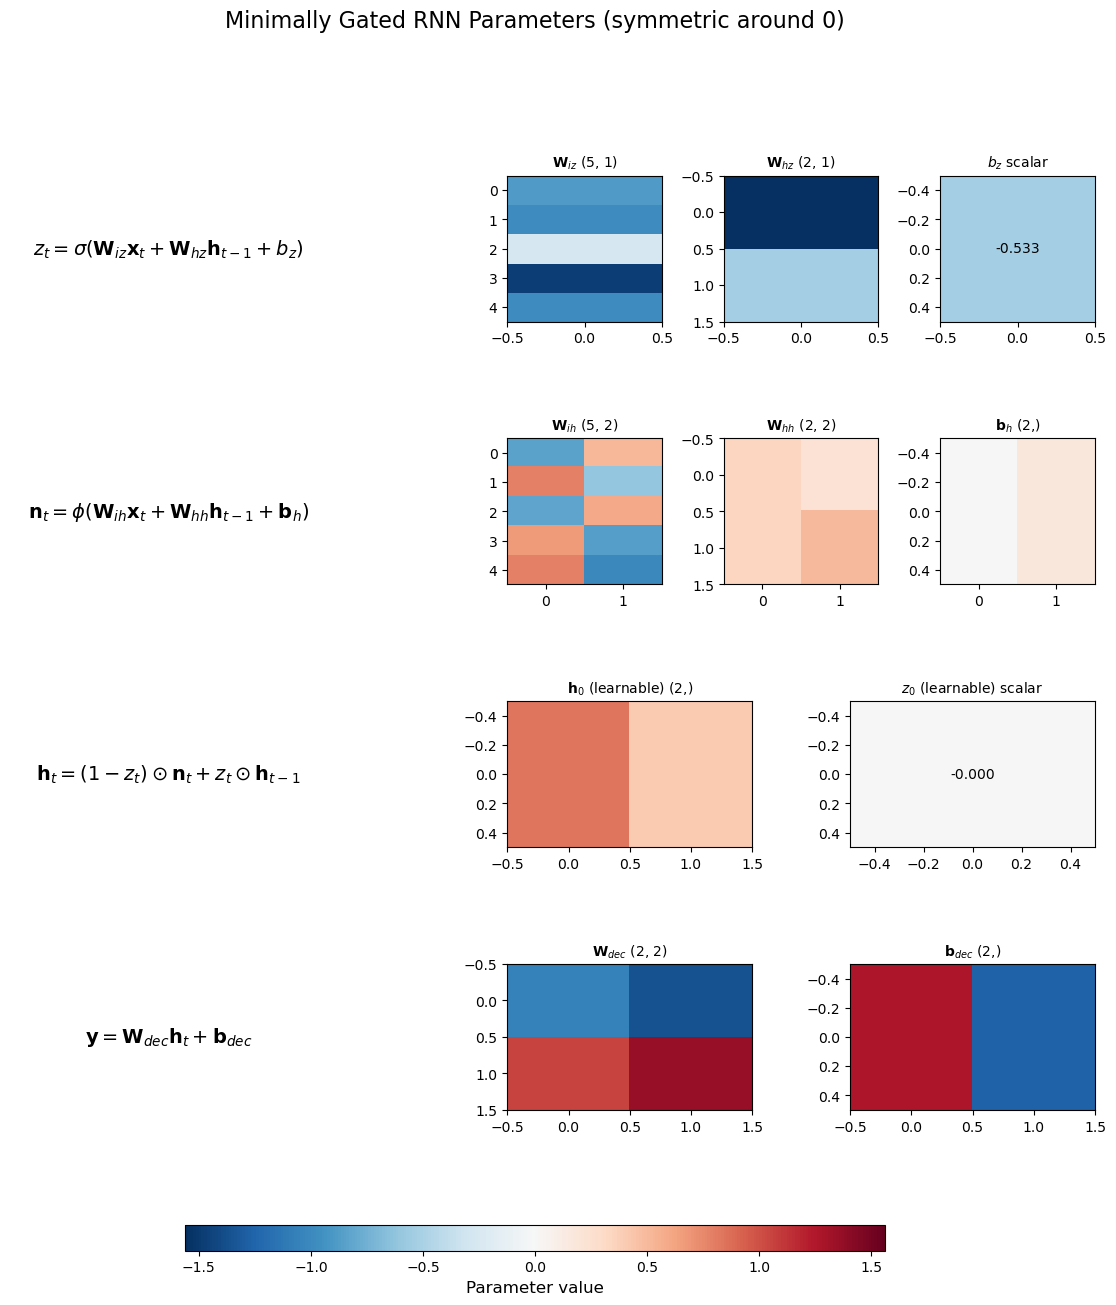

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import torch  # in case you still have tensor parameters

def plot_rnn_parameters(param_dict, include_decoder=False):
    """
    Visualise the parameters of a minimally gated RNN.
    
    Parameters
    ----------
    param_dict : dict
        Dictionary containing the RNN parameters. Expected keys:
        'rnn.W_ih', 'rnn.W_hh', 'rnn.W_iz', 'rnn.W_hz',
        'rnn.bias_h', 'rnn.bias_z', 'rnn.hidden_0', 'rnn.z_0'.
        If include_decoder=True, also 'decoder.weight' and 'decoder.bias'.
    include_decoder : bool
        Whether to add an extra row for the decoder weights.
    """
    # Convert all tensors to numpy arrays (if needed)
    clean_dict = {}
    for k, v in param_dict.items():
        if isinstance(v, torch.Tensor):
            v = v.detach().cpu().numpy()
        else:
            v = np.asarray(v)   # ensure it's a numpy array
        clean_dict[k] = v

    # Gather all values to compute symmetric colour range
    all_vals = []
    for arr in clean_dict.values():
        all_vals.append(arr.ravel())
    all_vals = np.concatenate(all_vals)
    max_abs = max(abs(all_vals.min()), abs(all_vals.max()))
    vmin, vmax = -max_abs, max_abs

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.RdBu_r

    # Determine number of rows (add one for decoder if requested)
    n_rows = 3 + (1 if include_decoder else 0)
    fig = plt.figure(figsize=(14, 3.2 * n_rows))
    gs = GridSpec(n_rows, 2, figure=fig, width_ratios=[0.35, 0.65],
                  hspace=0.8, wspace=0.4, bottom=0.15)

    # ---------- helper to annotate scalars safely ----------
    def scalar_text(ax, val, pos=(0, 0)):
        """Place text on a 1x1 heatmap."""
        ax.text(pos[0], pos[1], f'{float(val):.3f}',
                ha='center', va='center',
                color='white' if abs(float(val)) > max_abs/2 else 'black')

    # ---------- First row: z_t ----------
    ax_eq1 = fig.add_subplot(gs[0, 0])
    ax_eq1.axis('off')
    eq1 = (r"$z_t = \sigma\left(\mathbf{W}_{iz}\mathbf{x}_t + "
           r"\mathbf{W}_{hz}\mathbf{h}_{t-1} + b_z\right)$")
    ax_eq1.text(0.5, 0.5, eq1, ha='center', va='center', fontsize=14,
                transform=ax_eq1.transAxes)

    subgs_z = gs[0, 1].subgridspec(1, 3, wspace=0.4)
    ax_Wiz = fig.add_subplot(subgs_z[0, 0])
    im_Wiz = ax_Wiz.imshow(clean_dict['rnn.W_iz'], aspect='auto', cmap=cmap, norm=norm)
    ax_Wiz.set_title(r'$\mathbf{W}_{iz}$ ' + str(clean_dict['rnn.W_iz'].shape), fontsize=10)

    ax_Whz = fig.add_subplot(subgs_z[0, 1])
    im_Whz = ax_Whz.imshow(clean_dict['rnn.W_hz'], aspect='auto', cmap=cmap, norm=norm)
    ax_Whz.set_title(r'$\mathbf{W}_{hz}$ ' + str(clean_dict['rnn.W_hz'].shape), fontsize=10)

    ax_bz = fig.add_subplot(subgs_z[0, 2])
    bz_val = clean_dict['rnn.bias_z'].item()  # extract scalar
    im_bz = ax_bz.imshow(np.atleast_2d(bz_val), aspect='auto', cmap=cmap, norm=norm)
    ax_bz.set_title(r'$b_z$ scalar', fontsize=10)
    scalar_text(ax_bz, bz_val)

    # ---------- Second row: n_t ----------
    ax_eq2 = fig.add_subplot(gs[1, 0])
    ax_eq2.axis('off')
    eq2 = (r"$\mathbf{n}_t = \phi\left(\mathbf{W}_{ih}\mathbf{x}_t + "
           r"\mathbf{W}_{hh}\mathbf{h}_{t-1} + \mathbf{b}_h\right)$")
    ax_eq2.text(0.5, 0.5, eq2, ha='center', va='center', fontsize=14,
                transform=ax_eq2.transAxes)

    subgs_n = gs[1, 1].subgridspec(1, 3, wspace=0.4)
    ax_Wih = fig.add_subplot(subgs_n[0, 0])
    im_Wih = ax_Wih.imshow(clean_dict['rnn.W_ih'], aspect='auto', cmap=cmap, norm=norm)
    ax_Wih.set_title(r'$\mathbf{W}_{ih}$ ' + str(clean_dict['rnn.W_ih'].shape), fontsize=10)

    ax_Whh = fig.add_subplot(subgs_n[0, 1])
    im_Whh = ax_Whh.imshow(clean_dict['rnn.W_hh'], aspect='auto', cmap=cmap, norm=norm)
    ax_Whh.set_title(r'$\mathbf{W}_{hh}$ ' + str(clean_dict['rnn.W_hh'].shape), fontsize=10)

    ax_bh = fig.add_subplot(subgs_n[0, 2])
    bh_vals = clean_dict['rnn.bias_h']  # shape (H,)
    im_bh = ax_bh.imshow(bh_vals.reshape(1, -1), aspect='auto', cmap=cmap, norm=norm)
    ax_bh.set_title(r'$\mathbf{b}_h$ ' + str(bh_vals.shape), fontsize=10)

    # ---------- Third row: h_t + initial states ----------
    ax_eq3 = fig.add_subplot(gs[2, 0])
    ax_eq3.axis('off')
    eq3 = (r"$\mathbf{h}_t = (1-z_t)\odot\mathbf{n}_t + "
           r"z_t\odot\mathbf{h}_{t-1}$")
    ax_eq3.text(0.5, 0.5, eq3, ha='center', va='center', fontsize=14,
                transform=ax_eq3.transAxes)

    subgs_h = gs[2, 1].subgridspec(1, 2, wspace=0.4)
    ax_h0 = fig.add_subplot(subgs_h[0, 0])
    h0_vals = clean_dict['rnn.hidden_0']  # shape (H,)
    im_h0 = ax_h0.imshow(h0_vals.reshape(1, -1), aspect='auto', cmap=cmap, norm=norm)
    ax_h0.set_title(r'$\mathbf{h}_{0}$ (learnable) ' + str(h0_vals.shape), fontsize=10)

    ax_z0 = fig.add_subplot(subgs_h[0, 1])
    z0_val = clean_dict['rnn.z_0'].item()  # extract scalar
    im_z0 = ax_z0.imshow(np.atleast_2d(z0_val), aspect='auto', cmap=cmap, norm=norm)
    ax_z0.set_title(r'$z_{0}$ (learnable) scalar', fontsize=10)
    scalar_text(ax_z0, z0_val)

    # ---------- Optional decoder row ----------
    if include_decoder:
        row = 3
        ax_eq4 = fig.add_subplot(gs[row, 0])
        ax_eq4.axis('off')
        eq4 = (r"$\mathbf{y} = \mathbf{W}_{dec}\mathbf{h}_t + \mathbf{b}_{dec}$")
        ax_eq4.text(0.5, 0.5, eq4, ha='center', va='center', fontsize=14,
                    transform=ax_eq4.transAxes)

        subgs_dec = gs[row, 1].subgridspec(1, 2, wspace=0.4)
        ax_Wdec = fig.add_subplot(subgs_dec[0, 0])
        Wdec = clean_dict['decoder.weight']
        im_Wdec = ax_Wdec.imshow(Wdec, aspect='auto', cmap=cmap, norm=norm)
        ax_Wdec.set_title(r'$\mathbf{W}_{dec}$ ' + str(Wdec.shape), fontsize=10)

        ax_bdec = fig.add_subplot(subgs_dec[0, 1])
        bdec = clean_dict['decoder.bias']
        im_bdec = ax_bdec.imshow(bdec.reshape(1, -1), aspect='auto', cmap=cmap, norm=norm)
        ax_bdec.set_title(r'$\mathbf{b}_{dec}$ ' + str(bdec.shape), fontsize=10)

    # ---------- Single shared colorbar ----------
    cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.02])
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax,
                        orientation='horizontal')
    cbar.set_label('Parameter value', fontsize=12)

    fig.suptitle('Minimally Gated RNN Parameters (symmetric around 0)', fontsize=16, y=1.01)
    plt.show()

# ------------------------------------------------------------------
# Example usage with your final_state_dict

# Plot without the decoder (the default)
plot_rnn_parameters(final_state_dict, include_decoder=True)

# Or with the decoder row
# plot_rnn_parameters(final_state_dict, include_decoder=True)

In [79]:
#Here we've got code to run all inner loops in parallel,  

outer_results = nc.run_outer_fold(model, dataset,
                                  outer_loop_number = 8,
                                  n_outer_loops = 10,
                                  save_path = test_save_path,
                                  trainer_kwargs = {'weight_seeds':list(range(1,11)),
                                                'sparsity_lambdas':[1e-1,1e-2,1e-3,1e-4,1e-5],
                                                 'energy_lambdas':[1e-1,1e-2,1e-3],
                                                 'hebbian_lambdas':[0.0],
                                                 'covariance_lambdas':[0.0],
                                                 'batch_size':16} )

print([d['val_loss'] for d in outer_results['inner_results']])


[outer 8/10]  outer eval: 19 blocks  |  9 inner folds  |  saving to NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy


  0%|          | 0/10000 [00:00<?, ?it/s]

Search complete. Best model index: 84. Val. loss: 0.4850477874279022
  Saved outer_fold_8/inner_fold_8 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_8/inner_fold_8  (val_loss=0.4850, eval_loss=0.5504)
Parallelizing 150 models on cpu


  0%|          | 0/10000 [00:00<?, ?it/s]

Search complete. Best model index: 118. Val. loss: 0.5121706128120422
  Saved outer_fold_8/inner_fold_5 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_8/inner_fold_5  (val_loss=0.5122, eval_loss=0.5551)
Parallelizing 150 models on cpu
Search complete. Best model index: 114. Val. loss: 0.5527690052986145
  Saved outer_fold_8/inner_fold_3 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_8/inner_fold_3  (val_loss=0.5528, eval_loss=0.5516)
Parallelizing 150 models on cpu
Search complete. Best model index: 114. Val. loss: 0.5953733325004578
  Saved outer_fold_8/inner_fold_1 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_8/inner_fold_1  (val_loss=0.5954, eval_loss=0.5522)
Parallelizing 150 models on cpu


...

Parallelizing 150 models on cpu
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu


  0%|          | 0/10000 [00:00<?, ?it/s],  1.13it/s]

Search complete. Best model index: 129. Val. loss: 0.6351908445358276
  Saved outer_fold_8/inner_fold_0 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_8/inner_fold_0  (val_loss=0.6352, eval_loss=0.5766)
Parallelizing 150 models on cpu


  2%|▏         | 230/10000 [03:17<2:20:00,  1.16it/s]


[0.6351908445358276, 0.6007561683654785, 0.5586214065551758, 0.5911937952041626, 0.5270344614982605, 0.5097875595092773, 0.5438085198402405, 0.5695083141326904, 0.47426989674568176]


In [80]:
print([d['val_loss'] for d in outer_results['inner_results']])


[0.6351908445358276, 0.6007561683654785, 0.5586214065551758, 0.5911937952041626, 0.5270344614982605, 0.5097875595092773, 0.5438085198402405, 0.5695083141326904, 0.47426989674568176]


In [ ]:
print([d['val_loss'] for d in outer_results['inner_results']])


[0.6365492343902588, 0.5953733325004578, 0.6054320335388184, 0.5527690052986145, 0.5282925367355347, 0.5121706128120422, 0.5950843691825867, 0.5260191559791565, 0.4850477874279022]


Search complete. Best model index: 88. Val. loss: 0.6054320335388184
  Saved outer_fold_8/inner_fold_2 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_8/inner_fold_2  (val_loss=0.6054, eval_loss=0.5617)


In [ ]:
outer_results

{'outer_loop_number': 8,
 'outer_eval_blocks': [106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124],
 'inner_results': [{'fold_idx': 0,
   'state_dict': {'rnn.W_ih': tensor([[ 0.5394, -0.5384],
            [ 0.1843,  0.3525]], requires_grad=True),
    'rnn.W_hh': tensor([[ 0.4532, -0.3405],
            [-0.5802,  0.5135]], requires_grad=True),
    'rnn.W_iz': tensor([[-0.0457],
            [-0.6428]], requires_grad=True),
    'rnn.W_hz': tensor([[-0.5401],
            [-0.4562]], requires_grad=True),
    'rnn.bias_h': tensor([-0.1137,  0.2260], requires_grad=True),
    'rnn.bias_z': tensor(0.3752, requires_grad=True),
    'rnn.hidden_0': tensor([-0.0703, -0.0438], requires_grad=True),
    'rnn.z_0': tensor([0.0012], requires_grad=True),
    'decoder.weight': tensor([[-0.6484,  0.6654],
            [ 0.6485, -0.6453]], requires_grad=True)},
   'config': (1e-05, 0.1, 0.0, 0.0, 10),
   'val_loss': 0.63519084453

Search complete. Best model index: 149. Val. loss: 0.5270344614982605
  Saved outer_fold_8/inner_fold_4 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_8/inner_fold_4  (val_loss=0.5270, eval_loss=0.5558)


## Training on HPC


In [19]:
from NM_TinyRNN.code.models import submit_jobs
from importlib import reload
#reload(submit_jobs)
#we load a dataframe with the subjects we want to train
info_df = submit_jobs.get_DA_info_df()
print(len(info_df))
info_df[info_df.completed==0]

3240


,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,decoder_bias,input_encoding,input_forced_choice,nm_size,nm_dim,nm_mode,model_id,save_path,data_path,completed
2,WS20,1,vanilla,1,tanh,sparsity,True,encoder,True,1,1,row,1_unit_vanilla_tanh_encoder_forced,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,NM_TinyRNN/data/AB_behaviour/WS20,0
3,WS20,1,vanilla,2,tanh,sparsity,True,encoder,True,1,1,row,2_unit_vanilla_tanh_encoder_forced,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,NM_TinyRNN/data/AB_behaviour/WS20,0
4,WS20,1,vanilla,1,tanh,sparsity,True,onehot,True,1,1,row,1_unit_vanilla_tanh_onehot_forced,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,NM_TinyRNN/data/AB_behaviour/WS20,0
5,WS20,1,vanilla,2,tanh,sparsity,True,onehot,True,1,1,row,2_unit_vanilla_tanh_onehot_forced,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,NM_TinyRNN/data/AB_behaviour/WS20,0
8,WS20,1,GRU,1,relu,energy,True,encoder,True,1,1,row,1_unit_GRU_relu_encoder_forced,NM_TinyRNN/data/rnns/nested_DA_128/WS20/GRU/en...,NM_TinyRNN/data/AB_behaviour/WS20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3224,WS09,10,GRU,2,relu,energy,True,onehot,True,1,1,row,2_unit_GRU_relu_onehot_forced,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/en...,NM_TinyRNN/data/AB_behaviour/WS09,0
3227,WS09,10,GRU,1,tanh,sparsity,True,encoder,True,1,1,row,1_unit_GRU_tanh_encoder_forced,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS09,0
3228,WS09,10,GRU,2,tanh,sparsity,True,encoder,True,1,1,row,2_unit_GRU_tanh_encoder_forced,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS09,0
3229,WS09,10,GRU,1,tanh,sparsity,True,onehot,True,1,1,row,1_unit_GRU_tanh_onehot_forced,NM_TinyRNN/data/rnns/nested_DA_128/WS09/GRU/sp...,NM_TinyRNN/data/AB_behaviour/WS09,0


In [20]:
submit_jobs.run_training(overwrite=False, test=False)

Submitting model training for WS20 to HPC
Submitted batch job 3179483
Submitting model training for WS20 to HPC
Submitted batch job 3179484
Submitting model training for WS20 to HPC
Submitted batch job 3179485
Submitting model training for WS20 to HPC
Submitted batch job 3179486
Submitting model training for WS20 to HPC
Submitted batch job 3179487
Submitting model training for WS20 to HPC
Submitted batch job 3179488
Submitting model training for WS20 to HPC
Submitted batch job 3179489
Submitting model training for WS20 to HPC
Submitted batch job 3179490
Submitting model training for WS20 to HPC
Submitted batch job 3179491
Submitting model training for WS20 to HPC
Submitted batch job 3179492
Submitting model training for WS20 to HPC
Submitted batch job 3179493
Submitting model training for WS20 to HPC
Submitted batch job 3179494
Submitting model training for WS20 to HPC
Submitted batch job 3179495
Submitting model training for WS14 to HPC
Submitted batch job 3179496
Submitting model tra

In [87]:
reload(submit_jobs)
submit_jobs.run_training(overwrite = True, test=False)

Submitting model training for WS20 to HPC
Submitted batch job 3176329
Submitting model training for WS20 to HPC
Submitted batch job 3176330
Submitting model training for WS20 to HPC
Submitted batch job 3176331
Submitting model training for WS20 to HPC
Submitted batch job 3176332
Submitting model training for WS20 to HPC
Submitted batch job 3176333
Submitting model training for WS20 to HPC
Submitted batch job 3176334
Submitting model training for WS20 to HPC
Submitted batch job 3176335
Submitting model training for WS20 to HPC
Submitted batch job 3176336
Submitting model training for WS20 to HPC
Submitted batch job 3176337
Submitting model training for WS20 to HPC
Submitted batch job 3176338
Submitting model training for WS20 to HPC
Submitted batch job 3176339
Submitting model training for WS20 to HPC
Submitted batch job 3176340
Submitting model training for WS20 to HPC
Submitted batch job 3176341
Submitting model training for WS20 to HPC
Submitted batch job 3176342
Submitting model tra

In [62]:
!squeue -u cburns

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           3176354       cpu NM_TinyR   cburns PD       0:00      1 (launch failed requeued held)
           3175534       cpu     bash   cburns  R   18:00:50      1 enc1-node1
           3176538       cpu NM_TinyR   cburns  R      51:07      1 enc3-node1
           3176539       cpu NM_TinyR   cburns  R      51:07      1 enc3-node1
           3176540       cpu NM_TinyR   cburns  R      51:07      1 enc3-node1
           3176537       cpu NM_TinyR   cburns  R      52:07      1 enc1-node4
           3176535       cpu NM_TinyR   cburns  R      57:37      1 enc3-node2
